In [ ]:
# imports
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [156]:
# constants

Q = 100 # dispersion constant
u = 1 # wind speed
H = 0 # height 

ay, by = 0.5, 0.92
az, bz = 0.5, 0.87

In [272]:
# generating data

def plume_function(x0, y0, z0, x, y, z):
    dx = max(x - x0, 0.0001)
    dy = max(y - y0, 0.0001)
    dz = max(z - z0, 0.0001)

    s_y = ay * dx**by
    s_z = az * dx**bz
    s_y = max(s_y, 0.00002)
    s_z = max(s_z, 0.00002)

    term1 = Q / (2 * np.pi * s_y * s_z * u)
    term2 = np.exp(-dy**2 / (2 * s_y**2))
    term3 = np.exp(-(dz - H)**2 / (2 * s_z**2))
    c = term1 * term2 * term3
    c = min(c, 300)
    return c


# def generate_3_points_on_sphere(source, radius):
#     source = np.array(source)
#     points = []

#     for _ in range(3):
#         # Random spherical coordinates
#         theta = np.random.uniform(0, 2 * np.pi)
#         phi = np.arccos(np.random.uniform(-1, 1))

#         # Spherical to Cartesian
#         x = radius * np.sin(phi) * np.cos(theta)
#         y = radius * np.sin(phi) * np.sin(theta)
#         z = radius * np.cos(phi)

#         # Shift by source position
#         point = source + np.array([x, y, z])
#         points.append(point)

#     return np.array(points)

import numpy as np

def generate_3_points_downwind(source, radius):
    source = np.array(source)
    points = []

    while len(points) < 3:
        # Random spherical coordinates
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.random.uniform(0, np.pi)

        # Spherical to Cartesian
        x = radius * np.sin(phi) * np.cos(theta)
        y = radius * np.sin(phi) * np.sin(theta)
        z = radius * np.cos(phi)

        point = source + np.array([x, y, z])

        # ✅ Only keep point if it is downwind (x > x0)
        if point[0] > source[0]:
            points.append(point)

    return np.array(points)


def generate_data(n_samples=10000):
    X, Y = [], []

    for _ in range(n_samples):
        x0, y0, z0 = np.random.uniform(0, 5, 3)
        source = [x0, y0, z0]

        radi = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 2, 3]
        
        total_samples = int(100/len(radi))
        sample = []
        for _ in range(total_samples):
            for r in radi:
                concentrations_drone = []
                drone_points = generate_3_points_downwind(source, r).tolist()
                # a = input()
                for drone in drone_points:
                    x, y, z = drone
                    c = plume_function(x0, y0, z0, x, y, z)
                    concentrations_drone.append(c)
                
                # if(concentrations_drone[0] < 1 or concentrations_drone[1] < 1 or concentrations_drone[2] < 1): 
                #     continue
                
                for index in range(3):
                    drone_points[index].append(concentrations_drone[index])
                sample.append(drone_points)
        X.append(sample)
        Y.append([x0, y0, z0])
        
    return np.array(X), np.array(Y)

In [273]:
# get data
X_train, Y_train = generate_data(10000)
X_val, Y_val = generate_data(1000)

In [277]:
X_train_reshaped = X_train.reshape((X_train.shape[0], 96, 3 * 4))
X_val_reshaped = X_val.reshape((X_val.shape[0], 96, 3 * 4))

In [278]:
print(len(X_train)) # 100
print(len(X_train[0])) # 100
print(len(X_train[0][0])) # 3
print(len(X_train[0][0][0])) # 4

10000
96
3
4


In [283]:
# loss function
def euclidean_distance_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.sqrt(tf.reduce_sum(tf.square(y_true - y_pred), axis=1) + 1e-6))

def calculate_3d_error(predictions, true_values):
    return np.linalg.norm(predictions - true_values, axis=1)

import tensorflow as tf
import math

def plume_function_loss(x0, y0, z0, x, y, z, Q=100.0, u=1.0, ay=1.0, by=0.92, az=1.0, bz=0.87):
    dx = tf.maximum(tf.abs(x - x0), 0.0001)
    dy = y - y0
    dz = z - z0

    sigma_y = tf.maximum(ay * tf.pow(dx, by), 0.0002)
    sigma_z = tf.maximum(az * tf.pow(dx, bz), 0.0002)

    part1 = Q / (2.0 * math.pi * u * sigma_y * sigma_z)
    part2 = tf.exp(-0.5 * tf.square(dy / sigma_y))
    part3 = tf.exp(-0.5 * tf.square(dz / sigma_z))

    return part1 * part2 * part3


def conc_loss(y_true, y_pred):
    # Unpack true and predicted positions
    x0, y0, z0 = tf.unstack(y_true, axis=-1)
    x, y, z = tf.unstack(y_pred, axis=-1)

    # Concentration loss (how well predicted position reproduces known concentration)
    c_true = 200.0  # Or use tf.constant if you want
    c_pred = plume_function_loss(x0, y0, z0, x, y, z)
    conc_loss_val = tf.abs(c_true - c_pred)

    # Position loss (Euclidean distance)
    pos_loss_val = tf.norm(y_true - y_pred, axis=-1)

    # Combine both (equal weighting)
    total_loss = 0.5 * conc_loss_val + 0.5 * pos_loss_val
    return total_loss




In [ ]:
print()

In [240]:
import tensorflow as tf
from tensorflow.keras import layers

class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()
        self.W = layers.Dense(64, activation='tanh')
        self.V = layers.Dense(1)

    def call(self, inputs):
        # inputs shape: (batch_size, timesteps, features)
        score = self.V(self.W(inputs))          # (batch, timesteps, 1)
        attention_weights = tf.nn.softmax(score, axis=1)  # softmax over timesteps
        context_vector = attention_weights * inputs       # weighted features
        context_vector = tf.reduce_sum(context_vector, axis=1)  # sum over timesteps
        return context_vector


In [ ]:
from tensorflow.keras import Input, Model

inputs = Input(shape=(96, 12))
x = layers.LSTM(128, return_sequences=True)(inputs)

# Add attention here
x = AttentionLayer()(x)  # output shape: (batch, 128)

x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(3, activation='sigmoid')(x)

source = Model(inputs, outputs)
source.summary()


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_43 (InputLayer)     │ (None, 100, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_87 (LSTM)                  │ (None, 100, 128)       │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │         8,321 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,740 (331.02 KB)

 Trainable params: 84,740 (331.02 KB)

 Non-trainable params: 0 (0.00 B)

In [284]:
# # build LSTM
source = keras.Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(96, 12)),
    layers.LSTM(16),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='sigmoid'),  # 3 * 4 = 12
])

# compile model using adam optimizer and euclidean distance as a loss function
source.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=conc_loss)

# Train the model
history = source.fit(X_train_reshaped, Y_train,
                     validation_data=(X_val_reshaped, Y_val),
                     epochs=800,
                     batch_size=100,
                     verbose=1)

Epoch 1/800


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - loss: 101.0131 - val_loss: 100.9648
Epoch 2/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - loss: 100.7582 - val_loss: 100.6647
Epoch 3/800
 31/100 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 100.7521

KeyboardInterrupt: 

In [285]:
import tensorflow as tf
from tensorflow.keras import layers, Input, Model

# Suppose input shape: (batch, timesteps=100, features=12)
input_layer = Input(shape=(96, 12))

# Reshape input to separate drones and features
# 3 drones, 4 features per drone: reshape to (batch, timesteps, drones=3, features=4)
x = layers.Reshape((96, 3, 4))(input_layer)

# Separate position and concentration features
positions = x[:, :, :, :3]       # shape (batch, 100, 3, 3)
concentrations = x[:, :, :, 3:]  # shape (batch, 100, 3, 1)

# Flatten drones into feature dimension for each branch to process sequences of shape (batch, timesteps, features)
pos_seq = layers.Reshape((96, 3 * 3))(positions)          # (batch, 100, 9)
conc_seq = layers.Reshape((96, 3 * 1))(concentrations)   # (batch, 100, 3)

# Process positions branch with LSTM
pos_lstm = layers.LSTM(128, return_sequences=False)(pos_seq)  # (batch, 64)

# Process concentrations branch with LSTM
conc_lstm = layers.LSTM(128, return_sequences=False)(conc_seq)  # (batch, 32)

# Combine both branches
combined = layers.Concatenate()([pos_lstm, conc_lstm])  # (batch, 96)

# Dense layers to predict source coordinates
dense1 = layers.Dense(64, activation='relu')(combined)
output = layers.Dense(3)(dense1)  # predict (x0, y0, z0)

source = Model(inputs=input_layer, outputs=output)

# model.compile(optimizer='adam', loss=conc_loss)
source.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss=conc_loss)

# Train the model
history = source.fit(X_train_reshaped, Y_train,
                     validation_data=(X_val_reshaped, Y_val),
                     epochs=800,
                     batch_size=100,
                     verbose=1)
source.summary()


Epoch 1/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 101.3175 - val_loss: 99.5547
Epoch 2/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - loss: 98.7744 - val_loss: 99.4253
Epoch 3/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - loss: 101.6003 - val_loss: 99.5120
Epoch 4/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - loss: 99.4992 - val_loss: 99.2509
Epoch 5/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - loss: 99.2524 - val_loss: 98.9701
Epoch 6/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - loss: 98.9587 - val_loss: 98.4906
Epoch 7/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - loss: 98.5517 - val_loss: 98.5355
Epoch 8/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - loss: 98.2647 - val_loss: 98.0066
Epoch 9/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 565ms/step - loss: 97.8492 - val_loss: 98.0245
Epoch 10/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - loss: 97.4176 - val_loss: 99.7415
Epoch 11/800
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - loss: 96.9872 - va

KeyboardInterrupt: 

In [260]:
# Give in source number
def point_spread(dataset_x, dataset_y, height_slice, point=0):
    allPoints = dataset_x[point]
    x_points = []
    y_points = []
    z_points = []
    concentrations = []

    for points in allPoints:       # points shape: (3, 4) per timestep probably
        for drone in points:
            x_points.append(drone[0])
            y_points.append(drone[1])
            z_points.append(drone[2])
            concentrations.append(drone[3])

    print("Actual Source: ", dataset_y[point])
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.hist(x_points, bins=50, color='red', edgecolor='black')
    plt.xlabel('X')
    plt.ylabel('Frequency')
    plt.title('X Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 2)
    plt.hist(y_points, bins=50, color='green', edgecolor='black')
    plt.xlabel('Y')
    plt.title('Y Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 3)
    plt.hist(z_points, bins=50, color='blue', edgecolor='black')
    plt.xlabel('Z')
    plt.title('Z Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 4)
    plt.hist(concentrations, bins=50, range=(0, 0.001), color='skyblue', edgecolor='black')
    plt.xlabel('Concentration')
    plt.title('Concentration Distribution')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Grid
    x_range = np.linspace(0, 10, 10)    # downwind
    y_range = np.linspace(0, 10, 10)    # lateral
    z_plane = height_slice                           # fixed height cross-section

    # Evaluate on cross-section at z
    X, Y = np.meshgrid(x_range, y_range, indexing='ij')
    Z = np.full_like(X, z_plane)
    C = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            C[i, j] = plume_function(dataset_y[point][0], dataset_y[point][1], dataset_y[point][2], X[i, j], Y[i, j], Z[i, j])

    plt.contourf(X, Y, C, levels=50, cmap='inferno')
    plt.colorbar(label='Concentration')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Pollution at z={z_plane}')
    plt.show()


Actual Source:  [2.97123605 3.48739498 1.8578719 ]


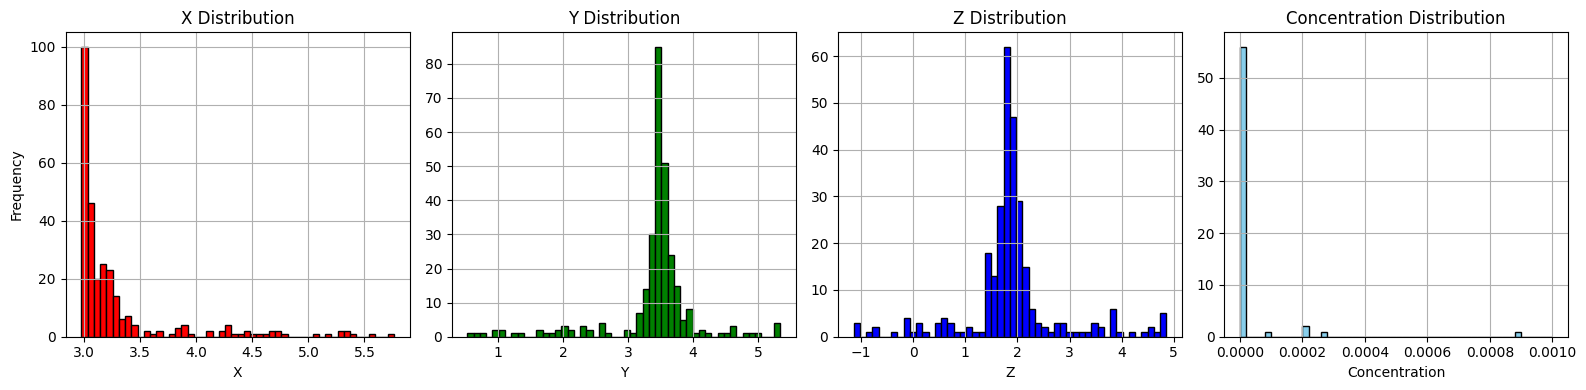

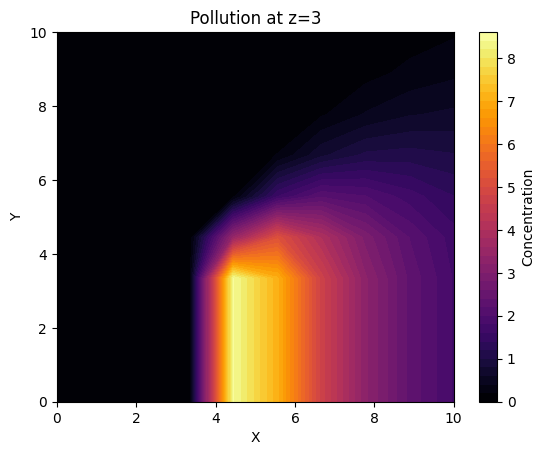

In [279]:
point_spread(X_train, Y_train, height_slice=3)

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_4d(X, Y, Z, C):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Normalize colors
    p = ax.scatter(X, Y, Z, c=C, cmap='viridis', marker='o', s=10)
    fig.colorbar(p, label='Concentration (4th dimension)')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('4D Plot: X, Y, Z + Concentration')
    plt.tight_layout()
    plt.show()


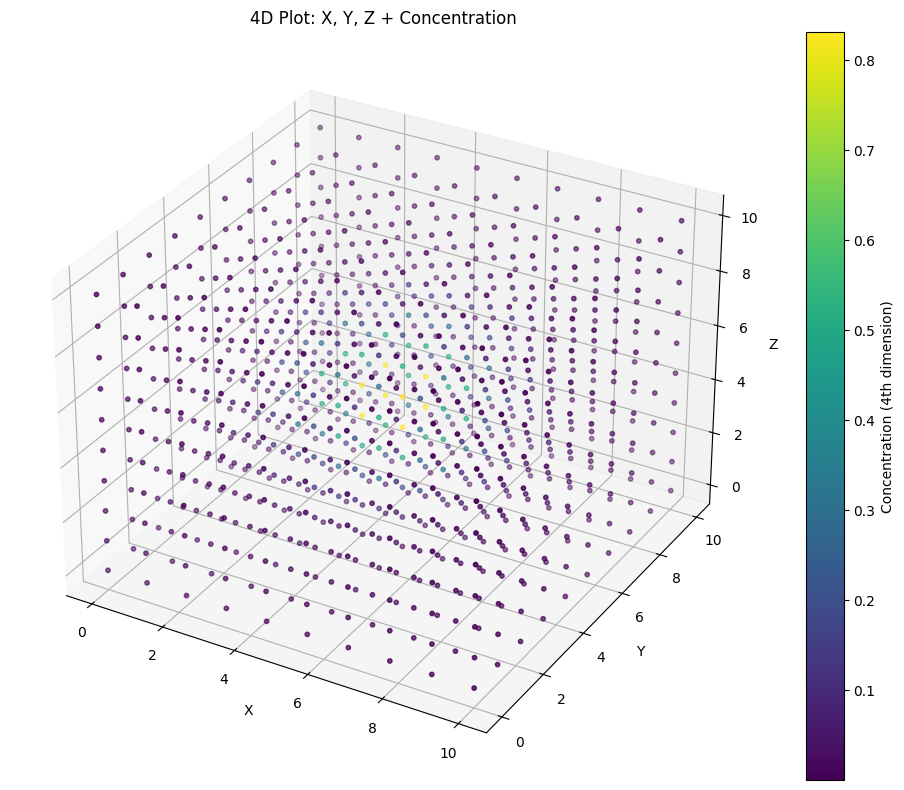

In [235]:

# Generate a simple 3D grid
x = np.linspace(0, 10, 10)
y = np.linspace(0, 10, 10)
z = np.linspace(0, 10, 10)

Xg, Yg, Zg = np.meshgrid(x, y, z)
X_flat = Xg.flatten()
Y_flat = Yg.flatten()
Z_flat = Zg.flatten()

# Example: 4th dimension = a 3D Gaussian (centered at 5,5,5)
C = np.exp(-((X_flat - 5)**2 + (Y_flat - 5)**2 + (Z_flat - 5)**2) / 5)

plot_4d(X_flat, Y_flat, Z_flat, C)

LSTM - for single point and calculating distance

In [ ]:
def plume_function_loss(x0, y0, z0, x, y, z, Q=100.0, u=1.0, ay=1.0, by=0.92, az=1.0, bz=0.87):
    dx = tf.maximum(tf.abs(x - x0), 0.0001)
    dy = y - y0
    dz = z - z0

    sigma_y = tf.maximum(ay * tf.pow(dx, by), 0.0002)
    sigma_z = tf.maximum(az * tf.pow(dx, bz), 0.0002)

    part1 = Q / (2.0 * math.pi * u * sigma_y * sigma_z)
    part2 = tf.exp(-0.5 * tf.square(dy / sigma_y))
    part3 = tf.exp(-0.5 * tf.square(dz / sigma_z))

    return part1 * part2 * part3


def conc_loss(y_true, y_pred):
    # Unpack true and predicted positions
    x0, y0, z0 = tf.unstack(y_true, axis=-1)
    x, y, z = tf.unstack(y_pred, axis=-1)

    # Concentration loss (how well predicted position reproduces known concentration)
    c_true = 200.0  # Or use tf.constant if you want
    c_pred = plume_function_loss(x0, y0, z0, x, y, z)
    conc_loss_val = tf.abs(c_true - c_pred)

    # Position loss (Euclidean distance)
    pos_loss_val = tf.norm(y_true - y_pred, axis=-1)

    # Combine both (equal weighting)
    total_loss = conc_loss_val
    return total_loss

In [422]:
# generating data

# constants

Q = 1000 # dispersion constant
u = 0.5 # wind speed
H = 0 # height 

ay, by = 0.4, 0.8
az, bz = 1, 0.8

def plume_function(x0, y0, z0, x, y, z):
    ay = 0.1  # increase base horizontal spread
    az = 0.4  # increase base vertical spread
    by = 0.5  # more aggressive horizontal growth
    bz = 0.6  # more aggressive vertical growth

    dx = max(x - x0, 0.0001)
    dy = max(y - y0, 0.0001)
    dz = max(z - z0, 0.0001)

    s_y = ay * dx**by
    s_z = az * dx**bz
    s_y = max(s_y, 0.00002)
    s_z = max(s_z, 0.00002)

    term1 = Q / (2 * np.pi * s_y * s_z * u)
    term2 = np.exp(-dy**2 / (2 * s_y**2))
    term3 = np.exp(-(dz - H)**2 / (2 * s_z**2))
    c = term1 * term2 * term3
    return c

# def generate_3_points_on_sphere(source, radius):
#     source = np.array(source)
#     points = []

#     for _ in range(3):
#         # Random spherical coordinates
#         theta = np.random.uniform(0, 2 * np.pi)
#         phi = np.arccos(np.random.uniform(-1, 1))

#         # Spherical to Cartesian
#         x = radius * np.sin(phi) * np.cos(theta)
#         y = radius * np.sin(phi) * np.sin(theta)
#         z = radius * np.cos(phi)

#         # Shift by source position
#         point = source + np.array([x, y, z])
#         points.append(point)

#     return np.array(points)

import numpy as np

def generate_3_points_downwind(source, radius):
    source = np.array(source)
    points = []

    while len(points) < 1:
        # Random spherical coordinates
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.random.uniform(0, np.pi)

        # Spherical to Cartesian
        x = radius * np.sin(phi) * np.cos(theta)
        y = radius * np.sin(phi) * np.sin(theta)
        z = radius * np.cos(phi)

        point = source + np.array([x, y, z])

        # ✅ Only keep point if it is downwind (x > x0)
        if point[0] > source[0]:
            points.append([point, x, y, z])

    return points[0][0], points[0][1], points[0][2], points[0][3]


def generate_data(n_samples=100000):
    X, Y = [], []

    for _ in range(n_samples):
        x0, y0, z0 = np.random.uniform(0, 5, 3)
        source = [x0, y0, z0]

        radi = [1, 1.5, 2,2.5, 3, 3.5,4, 5]
        
        total_samples = int(100/len(radi))
        sample = []
        for r in radi:
            concentrations_drone = []
            point, dx, dy, dz = generate_3_points_downwind(source, r)
            point = point.tolist()
            # a = input()
            x, y, z = point
            c = plume_function(x0, y0, z0, x, y, z)
            point.append(np.log(c + 0.00000001))
            
            X.append([point])
            Y.append([dx, dy, dz])
        
    return np.array(X), np.array(Y)

In [423]:
X, Y = generate_data()

In [397]:
point_spread(X, Y, height_slice=3)

IndexError: invalid index to scalar variable.

In [425]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Example parameters
sequence_length = 1  # number of measurement points per sample
feature_dim = 4      # x, y, z, concentration
output_dim = 3       # source x,y,z

# Define LSTM model
def build_lstm_model(sequence_length, feature_dim, output_dim):
    inputs = layers.Input(shape=(sequence_length, feature_dim))
    
    # LSTM layer(s)
    x = layers.LSTM(128, return_sequences=False)(inputs)  # output shape: (batch_size, 64)
    
    # Optional: add dense layers for more capacity
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    
    # Final output layer: source coordinates
    outputs = layers.Dense(output_dim)(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)  # or any rate you want
    model.compile(optimizer=optimizer, loss='mse')
    # model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_model(sequence_length, feature_dim, output_dim)
model.summary()

history = model.fit(X, Y, epochs=20, batch_size=64, validation_split=0.1)


Model: "functional_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_71 (InputLayer)     │ (None, 1, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_123 (LSTM)                 │ (None, 128)            │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_164 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_165 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,531 (306.76 KB)

 Trainable params: 78,531 (306.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.8153 - val_loss: 0.7627
Epoch 2/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7629 - val_loss: 0.7555
Epoch 3/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.7560 - val_loss: 0.7471
Epoch 4/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.7553 - val_loss: 0.7533
Epoch 5/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7531 - val_loss: 0.7514
Epoch 6/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7529 - val_loss: 0.7529
Epoch 7/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7503 - val_loss: 0.7546
Epoch 8/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7515 - val_loss: 0.7425
Epoch 9/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7508 - val_loss: 0.7523
Epoch 10/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7501 - val_loss: 0.7526
Epoch 11/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7476 - val_loss: 0.74

In [426]:
# source point: (3, 3, 3)
# drone_point: (2, 2, 2)

def plume_function(x0, y0, z0, x, y, z):
    ay = 0.3  # increase base horizontal spread
    az = 0.4  # increase base vertical spread
    by = 0.6  # more aggressive horizontal growth
    bz = 0.6  # more aggressive vertical growth

    dx = max(x - x0, 0.0001)
    dy = max(y - y0, 0.0001)
    dz = max(z - z0, 0.0001)

    s_y = ay * dx**by
    s_z = az * dx**bz
    s_y = max(s_y, 0.00002)
    s_z = max(s_z, 0.00002)

    term1 = Q / (2 * np.pi * s_y * s_z * u)
    term2 = np.exp(-dy**2 / (2 * s_y**2))
    term3 = np.exp(-(dz - H)**2 / (2 * s_z**2))
    c = term1 * term2 * term3
    return np.log(c + 0.00001)


source_point = [0, 0, 1]
drone_point = [1, 1, 1]

c = plume_function(source_point[0], source_point[1], source_point[2], drone_point[0], drone_point[1], drone_point[2])

features = np.array([drone_point[0], drone_point[1], drone_point[2], c])

# Add batch dimension (1 sample) and sequence length dimension (1 time step)
input_for_model = features.reshape((1, 1, 4))  # shape: (batch_size=1, seq_len=1, feature_dim=4)

# Now predict
predicted = model.predict(input_for_model)

dx, dy, dz = predicted[0]  # get first (and only) prediction in batch

print(f"Predicted displacement: dx={dx}, dy={dy}, dz={dz}")
print(c)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted displacement: dx=0.4198566675186157, dy=-0.2793152332305908, dz=-0.6125688552856445
2.3277343176921304


In [440]:
source_point = [0, 2, 2]
drone_point = [0, 2, 2]

c = plume_function(source_point[0], source_point[1], source_point[2], drone_point[0], drone_point[1], drone_point[2])

features = np.array([drone_point[0], drone_point[1], drone_point[2], c])

# Add batch dimension (1 sample) and sequence length dimension (1 time step)
input_for_model = features.reshape((1, 1, 4))  # shape: (batch_size=1, seq_len=1, feature_dim=4)

# Now predict
predicted = model.predict(input_for_model)

dx, dy, dz = predicted[0]  # get first (and only) prediction in batch

print(f"Predicted displacement: dx={dx}, dy={dy}, dz={dz}")
print(c)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted displacement: dx=-0.13648438453674316, dy=-0.35536688566207886, dz=-1.6550031900405884
18.93022031542236


In [431]:
source_point = [0, 0, 0]
drone_point = [0.5, 1, 1.5]

c = plume_function(source_point[0], source_point[1], source_point[2], drone_point[0], drone_point[1], drone_point[2])

features = np.array([drone_point[0], drone_point[1], drone_point[2], c])

# Add batch dimension (1 sample) and sequence length dimension (1 time step)
input_for_model = features.reshape((1, 1, 4))  # shape: (batch_size=1, seq_len=1, feature_dim=4)

# Now predict
predicted = model.predict(input_for_model)

dx, dy, dz = predicted[0]  # get first (and only) prediction in batch

print(f"Predicted displacement: dx={dx}, dy={dy}, dz={dz}")
print(c)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted displacement: dx=0.2449512481689453, dy=-0.05111294984817505, dz=-0.004315588623285294
-11.512757033042382
